# Proyek Analisis Data: E-Commerce Public Dataset (Fokus: Persebaran Wilayah Pelanggan)

- **Nama:** [Input Nama]
- **Email:** [Input Email]
- **ID Dicoding:** [Input Username]


## Menentukan Pertanyaan Bisnis

Analisis ini berfokus pada **persebaran wilayah pelanggan (customer geographic distribution)** Olist Store, sebuah e-commerce di Brazil, guna mendukung keputusan ekspansi logistik dan target campaign regional.

- **Pertanyaan 1:** Bagaimana distribusi jumlah pelanggan Olist berdasarkan negara bagian (state) dan 10 kota teratas hingga akhir periode data (Oktober 2018), dan wilayah mana yang paling mendominasi basis pelanggan?
- **Pertanyaan 2:** Apakah terdapat kesenjangan (gap) konsentrasi pelanggan antara wilayah Southeast (SP, RJ, MG, ES) dengan wilayah lain di Brazil, dan seberapa besar proporsinya terhadap total pelanggan?


## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import MarkerCluster, HeatMap

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


## Data Wrangling

### Gathering Data
Memuat dataset `customers_dataset.csv` dan `geolocation_dataset.csv` ke dalam DataFrame.

In [2]:
customers_df = pd.read_csv("data/customers_dataset.csv")
geolocation_df = pd.read_csv("data/geolocation_dataset.csv")

print("Customers dataset:")
display(customers_df.head())
print("\nGeolocation dataset:")
display(geolocation_df.head())


Customers dataset:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP



Geolocation dataset:


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [3]:
print("Shape customers_df :", customers_df.shape)
print("Shape geolocation_df:", geolocation_df.shape)


Shape customers_df : (99441, 5)
Shape geolocation_df: (1000163, 5)


**Insight:**
- `customers_df` berisi 99.441 baris data pelanggan dengan 5 kolom, termasuk `customer_zip_code_prefix`, `customer_city`, dan `customer_state` yang menjadi kunci untuk analisis persebaran wilayah.
- `geolocation_df` berisi lebih dari 1 juta baris koordinat (lat/lng) yang terhubung ke `customers_df` melalui kolom zip code prefix, digunakan untuk analisis geospasial.


### Assessing Data
Menilai kualitas kedua dataset untuk menemukan missing value, data duplikat, dan outlier/nilai tidak valid.

In [4]:
# Cek info struktur data
customers_df.info()
print("-"*50)
geolocation_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 11.0 MB
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city            

In [5]:
# Cek missing value
print("Missing value customers_df:")
print(customers_df.isna().sum())
print("\nMissing value geolocation_df:")
print(geolocation_df.isna().sum())


Missing value customers_df:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Missing value geolocation_df:
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64


In [6]:
# Cek data duplikat
print("Jumlah baris duplikat penuh - customers_df   :", customers_df.duplicated().sum())
print("Jumlah baris duplikat penuh - geolocation_df :", geolocation_df.duplicated().sum())


Jumlah baris duplikat penuh - customers_df   : 0


Jumlah baris duplikat penuh - geolocation_df : 261831


In [7]:
# Cek outlier/nilai tidak valid pada koordinat geolocation
# Batas wilayah Brazil kurang lebih: lat -34 s/d 5, lng -74 s/d -34
print("Rentang latitude  :", geolocation_df["geolocation_lat"].min(), "s/d", geolocation_df["geolocation_lat"].max())
print("Rentang longitude :", geolocation_df["geolocation_lng"].min(), "s/d", geolocation_df["geolocation_lng"].max())

outlier_mask = ~geolocation_df["geolocation_lat"].between(-34, 6) | ~geolocation_df["geolocation_lng"].between(-74, -32)
print("Jumlah baris dengan koordinat di luar batas wajar Brazil:", outlier_mask.sum())


Rentang latitude  : -36.6053744107061 s/d 45.06593318269697
Rentang longitude : -101.46676644931476 s/d 121.10539381057764
Jumlah baris dengan koordinat di luar batas wajar Brazil: 31


In [8]:
# Cek konsistensi customer_id vs customer_unique_id
print("Jumlah customer_id unik      :", customers_df["customer_id"].nunique())
print("Jumlah customer_unique_id unik:", customers_df["customer_unique_id"].nunique())
print("Selisih (pelanggan dengan >1 order/customer_id):", customers_df["customer_id"].nunique() - customers_df["customer_unique_id"].nunique())


Jumlah customer_id unik      : 99441
Jumlah customer_unique_id unik: 96096
Selisih (pelanggan dengan >1 order/customer_id): 3345


**Steps to Take:**
- **Masalah 1 - Data duplikat pada `geolocation_df`**: ditemukan 261.831 baris duplikat penuh. Solusi: buang baris duplikat dengan `drop_duplicates()`.
- **Masalah 2 - Outlier/koordinat tidak valid**: sebagian titik lat/lng berada jauh di luar batas geografis Brazil (misal lat > 5 atau lng > -32), kemungkinan karena kesalahan input. Solusi: filter data agar hanya koordinat dalam rentang wajar wilayah Brazil yang dipertahankan.
- `customer_id` bersifat unik per transaksi/order, sedangkan `customer_unique_id` merepresentasikan pelanggan asli (ada pelanggan yang bertransaksi lebih dari sekali). Untuk analisis persebaran **jumlah pelanggan terdaftar**, kita tetap menggunakan `customer_id` sesuai granularitas dataset customers, sebagaimana lazim digunakan pada analisis Olist dataset.


**Insight:**
- Dataset `customers_df` sudah cukup bersih (tidak ada missing value maupun duplikat penuh).
- Dataset `geolocation_df` memerlukan proses cleaning pada sisi duplikasi baris dan outlier koordinat sebelum digunakan untuk analisis geospasial.


### Cleaning Data
Membersihkan `geolocation_df` dari data duplikat dan outlier koordinat, kemudian menyiapkan tabel agregat koordinat per zip code prefix untuk digabungkan dengan `customers_df`.

In [9]:
geolocation_clean = geolocation_df.copy()

# 1. Buang baris duplikat penuh
before = geolocation_clean.shape[0]
geolocation_clean = geolocation_clean.drop_duplicates()
print(f"Baris duplikat dibuang: {before - geolocation_clean.shape[0]}")

# 2. Buang outlier koordinat di luar batas wajar wilayah Brazil
before = geolocation_clean.shape[0]
geolocation_clean = geolocation_clean[
    geolocation_clean["geolocation_lat"].between(-34, 6) &
    geolocation_clean["geolocation_lng"].between(-74, -32)
]
print(f"Baris outlier koordinat dibuang: {before - geolocation_clean.shape[0]}")

print("Shape geolocation_clean akhir:", geolocation_clean.shape)


Baris duplikat dibuang: 261831
Baris outlier koordinat dibuang: 27
Shape geolocation_clean akhir: (738305, 5)


In [10]:
# Agregasi koordinat: rata-rata lat/lng per zip code prefix agar 1 baris = 1 zip prefix
geo_agg = (
    geolocation_clean
    .groupby("geolocation_zip_code_prefix")
    .agg(lat=("geolocation_lat", "mean"), lng=("geolocation_lng", "mean"))
    .reset_index()
    .rename(columns={"geolocation_zip_code_prefix": "customer_zip_code_prefix"})
)
geo_agg.head()


,customer_zip_code_prefix,lat,lng
0,1001,-23.550227,-46.634039
1,1002,-23.547657,-46.634991
2,1003,-23.549000,-46.635582
3,1004,-23.549829,-46.634792
4,1005,-23.549547,-46.636406


In [11]:
# Gabungkan customers_df dengan agregat koordinat geolocation
main_df = customers_df.merge(geo_agg, how="left", on="customer_zip_code_prefix")
print("Jumlah pelanggan tanpa koordinat setelah merge:", main_df["lat"].isna().sum())
main_df.head()


Jumlah pelanggan tanpa koordinat setelah merge: 279


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,lat,lng
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,-20.499273,-47.396658
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,-23.728396,-46.542250
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,-23.531309,-46.656690
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,-23.500670,-46.186348
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,-22.975708,-47.143140


In [12]:
# Tambahkan kolom customer_region hasil binning state -> 5 region resmi Brazil
# (dijelaskan lebih lanjut pada bagian Analisis Lanjutan)
region_map = {
    "SP": "Southeast", "RJ": "Southeast", "MG": "Southeast", "ES": "Southeast",
    "PR": "South", "RS": "South", "SC": "South",
    "BA": "Northeast", "PE": "Northeast", "CE": "Northeast", "MA": "Northeast",
    "PB": "Northeast", "RN": "Northeast", "AL": "Northeast", "SE": "Northeast", "PI": "Northeast",
    "GO": "Central-West", "DF": "Central-West", "MT": "Central-West", "MS": "Central-West",
    "AM": "North", "PA": "North", "RO": "North", "AC": "North", "AP": "North", "RR": "North", "TO": "North",
}
main_df["customer_region"] = main_df["customer_state"].map(region_map)
main_df.head()


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,lat,lng,customer_region
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,-20.499273,-47.396658,Southeast
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,-23.728396,-46.542250,Southeast
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,-23.531309,-46.656690,Southeast
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,-23.500670,-46.186348,Southeast
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,-22.975708,-47.143140,Southeast


**Insight:**
- Setelah dibersihkan, `geolocation_clean` bebas dari duplikasi dan koordinat outlier di luar wilayah Brazil.
- Agregasi ke level `zip_code_prefix` diperlukan karena satu zip code prefix memiliki banyak titik koordinat presisi tinggi; untuk kebutuhan analisis persebaran wilayah, satu titik representatif (rata-rata) per zip prefix sudah memadai.
- Hasil merge dan penambahan kolom `customer_region` (`main_df`) menjadi dataset utama yang dipakai pada tahap EDA, visualisasi, analisis lanjutan, **dan diekspor sebagai `main_data.csv` untuk dashboard Streamlit** (lihat sel export di akhir notebook).


## Exploratory Data Analysis (EDA)

Mengeksplorasi persebaran pelanggan berdasarkan state dan kota untuk menjawab pertanyaan bisnis.

In [13]:
# Ringkasan jumlah pelanggan per state
state_counts = main_df["customer_state"].value_counts().reset_index()
state_counts.columns = ["customer_state", "jumlah_pelanggan"]
state_counts["persentase"] = round(state_counts["jumlah_pelanggan"] / state_counts["jumlah_pelanggan"].sum() * 100, 2)
state_counts


,customer_state,jumlah_pelanggan,persentase
0,SP,41746,41.98
1,RJ,12852,12.92
2,MG,11635,11.70
3,RS,5466,5.50
4,PR,5045,5.07
5,SC,3637,3.66
6,BA,3380,3.40
7,DF,2140,2.15
8,ES,2033,2.04
9,GO,2020,2.03


In [14]:
# Ringkasan jumlah pelanggan per kota (top 10)
city_counts = main_df["customer_city"].value_counts().head(10).reset_index()
city_counts.columns = ["customer_city", "jumlah_pelanggan"]
city_counts


,customer_city,jumlah_pelanggan
0,sao paulo,15540
1,rio de janeiro,6882
2,belo horizonte,2773
3,brasilia,2131
4,curitiba,1521
5,campinas,1444
6,porto alegre,1379
7,salvador,1245
8,guarulhos,1189
9,sao bernardo do campo,938


In [15]:
# Ringkasan jumlah pelanggan per region (kolom customer_region sudah dibuat pada tahap Cleaning Data)
region_counts = main_df["customer_region"].value_counts().reset_index()
region_counts.columns = ["customer_region", "jumlah_pelanggan"]
region_counts["persentase"] = round(region_counts["jumlah_pelanggan"] / region_counts["jumlah_pelanggan"].sum() * 100, 2)
region_counts


,customer_region,jumlah_pelanggan,persentase
0,Southeast,68266,68.65
1,South,14148,14.23
2,Northeast,9394,9.45
3,Central-West,5782,5.81
4,North,1851,1.86


**Insight:**
- State **SP (Sao Paulo)** mendominasi jumlah pelanggan secara signifikan dibandingkan state lain.
- Kota **Sao Paulo** dan **Rio de Janeiro** menjadi dua kota dengan jumlah pelanggan tertinggi, konsisten dengan dominasi wilayah Southeast.
- Pengelompokan ke level region menunjukkan ketimpangan yang jauh lebih jelas antara Southeast dan region lain.


## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana distribusi jumlah pelanggan Olist berdasarkan state dan 10 kota teratas, dan wilayah mana yang paling mendominasi?

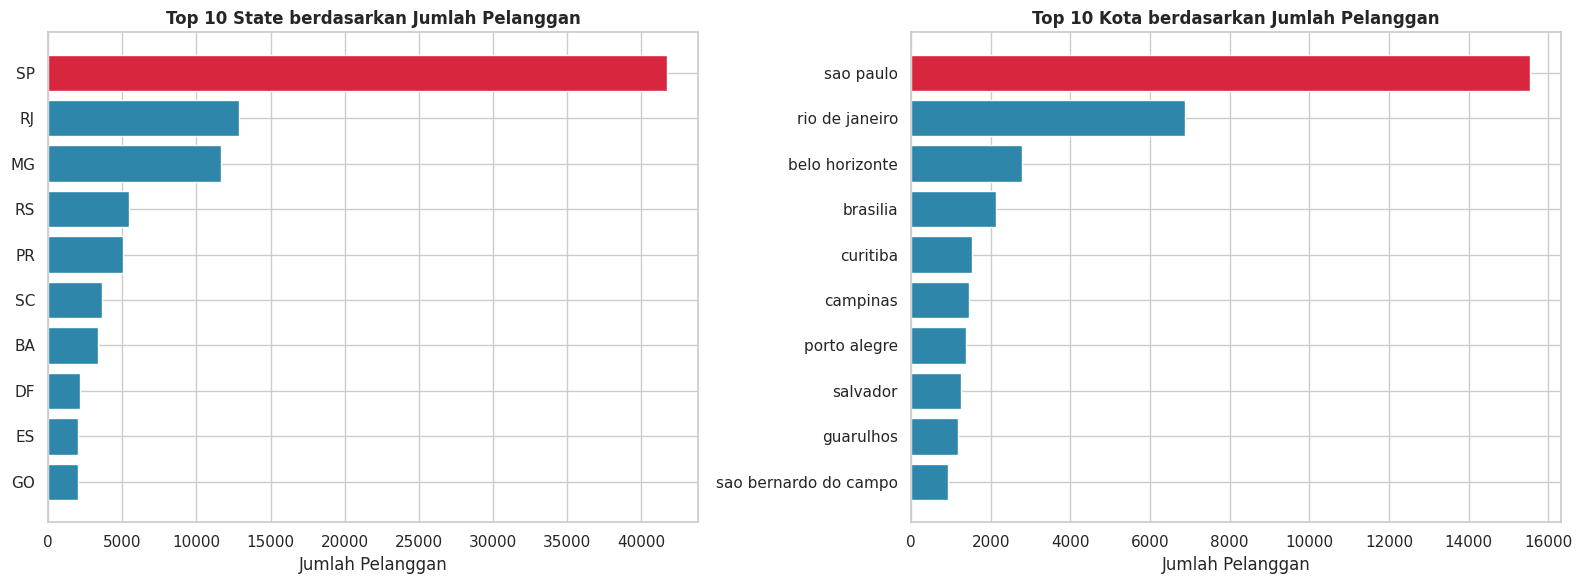

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top10_state = state_counts.head(10)
colors_state = ["#2E86AB" if s != "SP" else "#D7263D" for s in top10_state["customer_state"]]
axes[0].barh(top10_state["customer_state"][::-1], top10_state["jumlah_pelanggan"][::-1], color=colors_state[::-1])
axes[0].set_title("Top 10 State berdasarkan Jumlah Pelanggan", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Jumlah Pelanggan")

colors_city = ["#2E86AB" if c != "sao paulo" else "#D7263D" for c in city_counts["customer_city"]]
axes[1].barh(city_counts["customer_city"][::-1], city_counts["jumlah_pelanggan"][::-1], color=colors_city[::-1])
axes[1].set_title("Top 10 Kota berdasarkan Jumlah Pelanggan", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Jumlah Pelanggan")

plt.tight_layout()
plt.savefig("top_state_city.png", dpi=120, bbox_inches="tight")
plt.show()


### Pertanyaan 2: Apakah terdapat kesenjangan konsentrasi pelanggan antara wilayah Southeast dengan wilayah lain di Brazil?

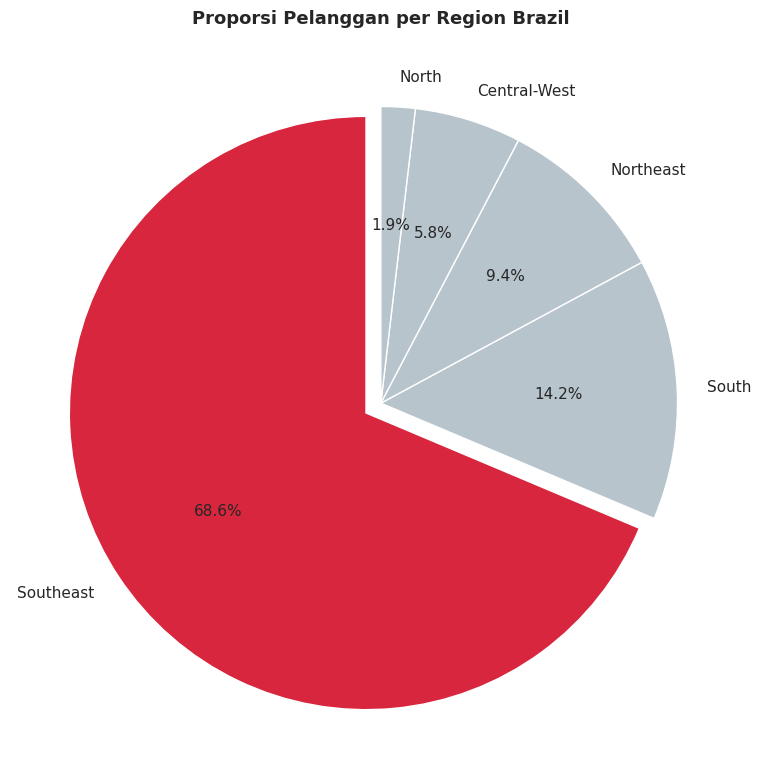

In [17]:
fig, ax = plt.subplots(figsize=(8, 8))
colors_region = ["#D7263D" if r == "Southeast" else "#B8C4CC" for r in region_counts["customer_region"]]
explode = [0.06 if r == "Southeast" else 0 for r in region_counts["customer_region"]]

ax.pie(
    region_counts["jumlah_pelanggan"],
    labels=region_counts["customer_region"],
    autopct="%1.1f%%",
    colors=colors_region,
    explode=explode,
    startangle=90,
    textprops={"fontsize": 11}
)
ax.set_title("Proporsi Pelanggan per Region Brazil", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("region_gap.png", dpi=120, bbox_inches="tight")
plt.show()


**Insight:**
- Visualisasi Pertanyaan 1 menegaskan bahwa state **SP** menyumbang porsi pelanggan terbesar secara ekstrem dibanding state lainnya, dan kota **Sao Paulo** sendiri menyumbang porsi terbesar dari total pelanggan.
- Visualisasi Pertanyaan 2 menunjukkan **kesenjangan region yang sangat besar**: wilayah **Southeast** menguasai mayoritas pelanggan, jauh melebihi gabungan seluruh wilayah lain (South, Northeast, Central-West, North).


## Analisis Lanjutan (Opsional)

Pada bagian ini diterapkan dua teknik analisis lanjutan tanpa algoritma machine learning yang relevan dengan fokus persebaran wilayah pelanggan:

1. **Geospatial Analysis** menggunakan `folium` untuk memvisualisasikan sebaran titik lokasi pelanggan pada peta interaktif Brazil.
2. **Clustering via Manual Grouping/Binning** yaitu pengelompokan state menjadi 5 region resmi Brazil (Southeast, South, Northeast, North, Central-West) berdasarkan aturan geografis administratif, untuk melihat pola konsentrasi pada level yang lebih tinggi dibanding state individual.


In [18]:
# Geospatial Analysis: peta sebaran pelanggan (sampel agar ringan dirender)
map_df = main_df.dropna(subset=["lat", "lng"]).sample(n=5000, random_state=42)

m = folium.Map(location=[-15.78, -47.93], zoom_start=4, tiles="CartoDB positron")
heat_data = list(zip(map_df["lat"], map_df["lng"]))
HeatMap(heat_data, radius=8, blur=6).add_to(m)
m.save("customer_distribution_map.html")
m


In [19]:
# Clustering (binning) berdasarkan region: rata-rata koordinat tiap region sebagai representasi pusat massa pelanggan
region_geo = main_df.dropna(subset=["lat", "lng"]).groupby("customer_region").agg(
    jumlah_pelanggan=("customer_id", "count"),
    lat=("lat", "mean"),
    lng=("lng", "mean")
).reset_index().sort_values("jumlah_pelanggan", ascending=False)
region_geo


,customer_region,jumlah_pelanggan,lat,lng
4,Southeast,68221,-22.447120,-45.679567
3,South,14132,-27.327761,-50.924709
2,Northeast,9364,-8.859207,-38.683949
0,Central-West,5600,-16.491601,-50.552854
1,North,1845,-4.765837,-52.962481


**Insight:**
- Peta *heatmap* memperlihatkan bahwa titik-titik pelanggan sangat terkonsentrasi di sepanjang koridor tenggara Brazil (sekitar Sao Paulo - Rio de Janeiro - Belo Horizonte), dan menipis drastis ke wilayah utara.
- Hasil binning region menegaskan kembali temuan kuantitatif sebelumnya: **Southeast** bukan hanya region dengan jumlah pelanggan terbanyak, namun juga tersebar padat secara spasial (bukan hanya di satu kota saja), sementara region lain seperti **North** memiliki jumlah pelanggan yang sangat sedikit dan tersebar renggang.


## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Distribusi pelanggan Olist sangat tidak merata secara geografis. State **SP (Sao Paulo)** mendominasi dengan jumlah pelanggan jauh di atas state lain, dan kota **Sao Paulo** menjadi kota dengan konsentrasi pelanggan tertinggi, diikuti Rio de Janeiro dan Belo Horizonte. Wilayah **Southeast** adalah wilayah yang paling mendominasi basis pelanggan Olist.
- **Conclusion pertanyaan 2:** Terdapat kesenjangan (gap) yang sangat besar antara region Southeast dan region lainnya. Southeast menguasai mayoritas pelanggan, sementara region seperti North dan Central-West memiliki proporsi yang jauh lebih kecil, menunjukkan penetrasi pasar Olist di luar Southeast masih rendah.

**Rekomendasi Action Item:**
- Memprioritaskan penambahan **gudang/hub logistik regional** di luar Southeast (misalnya di region Northeast atau South) untuk memperpendek waktu pengiriman dan mendorong pertumbuhan pelanggan di wilayah yang masih sedikit terlayani.
- Merancang **campaign marketing tertarget** khusus untuk region dengan penetrasi rendah (North, Central-West) guna memperluas basis pelanggan secara geografis, alih-alih terus berfokus pada wilayah Southeast yang sudah jenuh.


## Menyimpan Data Bersih untuk Dashboard

`main_df` merupakan hasil akhir dari seluruh proses *data wrangling* (gathering, assessing, cleaning) dan pengayaan kolom (`customer_region`) pada notebook ini. Dataset ini disimpan sebagai `main_data.csv` di dalam folder `dashboard/` agar dapat langsung dipakai oleh `dashboard.py` (Streamlit), sehingga dashboard selalu konsisten dengan hasil analisis pada notebook.

In [20]:
main_df.to_csv("dashboard/main_data.csv", index=False)
print("main_data.csv berhasil disimpan dengan shape:", main_df.shape)
main_df.head()


main_data.csv berhasil disimpan dengan shape: (99441, 8)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,lat,lng,customer_region
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,-20.499273,-47.396658,Southeast
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,-23.728396,-46.542250,Southeast
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,-23.531309,-46.656690,Southeast
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,-23.500670,-46.186348,Southeast
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,-22.975708,-47.143140,Southeast
